In [1]:
import pandas as pd

# Charger le fichier CSV
file_path = './data/dataP/preprocessed_winequality_dataset.csv'
df = pd.read_csv(file_path)

# Afficher les valeurs uniques triées pour chaque colonne
for column in df.columns:
    uniques = sorted(df[column].dropna().unique())  # tri des valeurs uniques en supprimant les NaN
    print(f"{column} ({len(uniques)} valeurs uniques):")
    print(uniques)
    print("-" * 50)


fixed acidity (96 valeurs uniques):
[4.6, 4.7, 4.9, 5.0, 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6.0, 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9, 7.0, 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 8.0, 8.1, 8.2, 8.3, 8.4, 8.5, 8.6, 8.7, 8.8, 8.9, 9.0, 9.1, 9.2, 9.3, 9.4, 9.5, 9.6, 9.7, 9.8, 9.9, 10.0, 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9, 11.0, 11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9, 12.0, 12.1, 12.2, 12.3, 12.4, 12.5, 12.6, 12.7, 12.8, 12.9, 13.0, 13.2, 13.3, 13.4, 13.5, 13.7, 13.8, 14.0, 14.3, 15.0, 15.5, 15.6, 15.9]
--------------------------------------------------
volatile acidity (143 valeurs uniques):
[0.12, 0.16, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.295, 0.3, 0.305, 0.31, 0.315, 0.32, 0.33, 0.34, 0.35, 0.36, 0.365, 0.37, 0.38, 0.39, 0.395, 0.4, 0.41, 0.415, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.475, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.545, 0.55, 0.56, 0.565, 0.57, 0.575, 0.58, 0.585, 0.59, 0.595, 0.6,

C:\Users\yando\AppData\Local\Temp\ipykernel_7488\2609046799.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  categorized_df.groupby(feature + "_cat")[feature].plot(kind='hist', bins=20, ax=ax, alpha=0.6, legend=True)
C:\Users\yando\AppData\Local\Temp\ipykernel_7488\2609046799.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  categorized_df.groupby(feature + "_cat")[feature].plot(kind='hist', bins=20, ax=ax, alpha=0.6, legend=True)
C:\Users\yando\AppData\Local\Temp\ipykernel_7488\2609046799.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version 

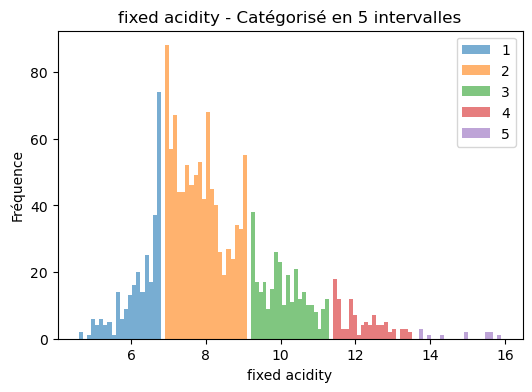

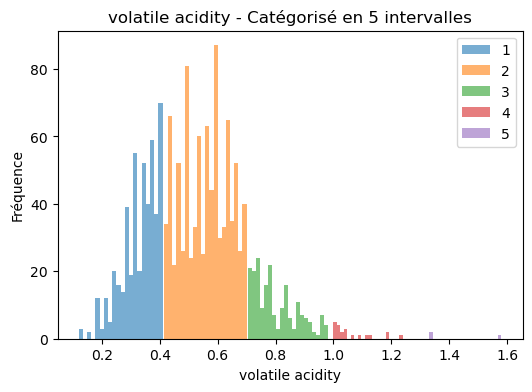

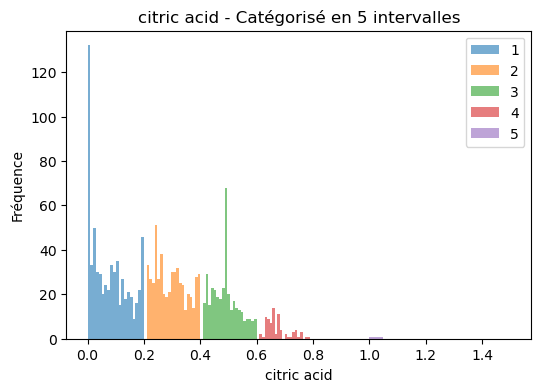

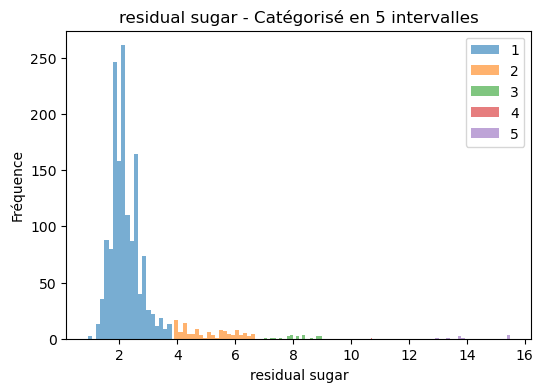

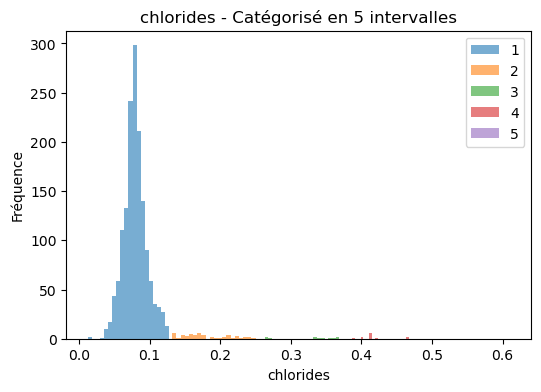

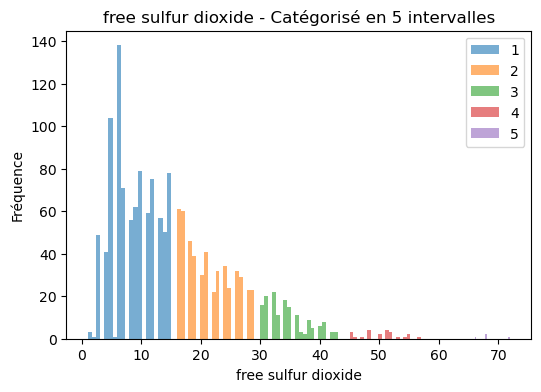

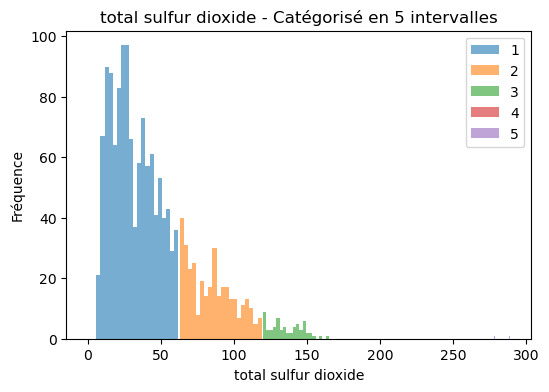

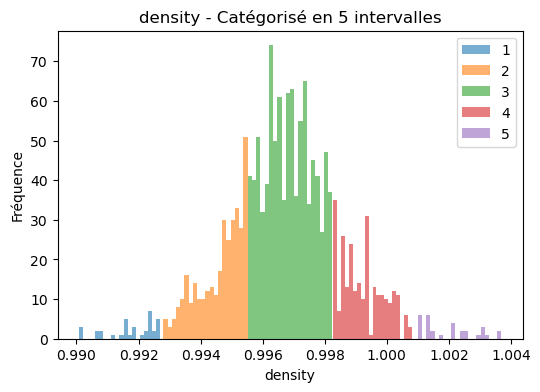

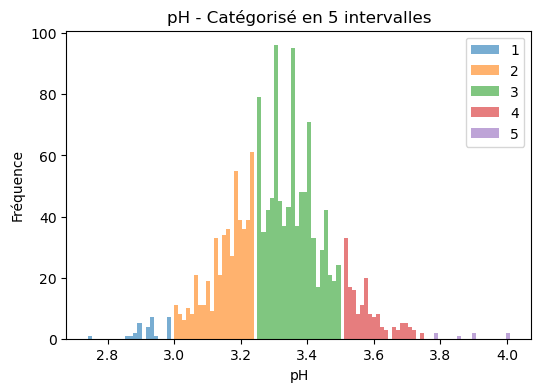

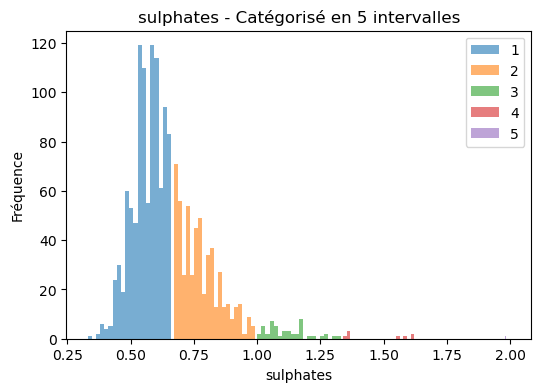

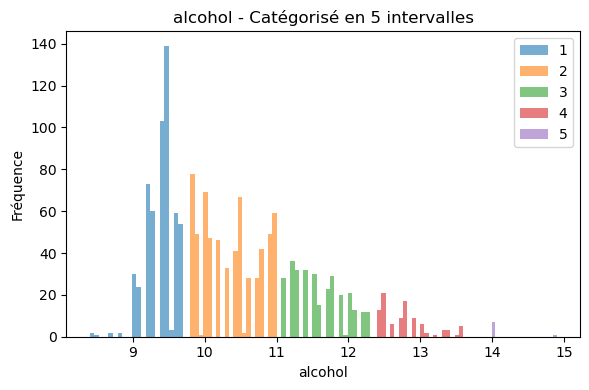

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Chargement du dataset winequality (rouge par exemple)
file_path = './data/dataP/preprocessed_winequality_dataset.csv'
wine_df = pd.read_csv(file_path)


# Génération des bins pour chaque feature (5 catégories)
bins_dict = {}
categorized_df = wine_df.copy()

# On exclut la colonne "quality" de la catégorisation
features = [col for col in wine_df.columns if col != "quality"]

for feature in features:
    min_val = wine_df[feature].min()
    max_val = wine_df[feature].max()
    bins = np.linspace(min_val, max_val, 6)  # 6 bornes pour 5 catégories
    labels = list(range(1, 6))  # 5 catégories
    categorized_df[feature + "_cat"] = pd.cut(wine_df[feature], bins=bins, labels=labels, include_lowest=True)
    bins_dict[feature] = bins

# Visualisation : Histogrammes avec coloration par catégorie
figures = []

for feature in features:
    fig, ax = plt.subplots(figsize=(6, 4))
    categorized_df.groupby(feature + "_cat")[feature].plot(kind='hist', bins=20, ax=ax, alpha=0.6, legend=True)
    ax.set_title(f"{feature} - Catégorisé en 5 intervalles")
    ax.set_xlabel(feature)
    ax.set_ylabel("Fréquence")
    figures.append(fig)

plt.tight_layout()
plt.show()


In [19]:
import pandas as pd
import numpy as np
from allpairspy import AllPairs

# Chargement du dataset winequality (rouge ou pré-traité)
file_path = './data/dataP/preprocessed_winequality_dataset.csv'
wine_df = pd.read_csv(file_path)

# Détection automatique des features (on exclut la qualité)
features = [col for col in wine_df.columns if col != "quality"]

# Définition des bins (5 catégories par feature)
bins_dict = {}
for feature in features:
    min_val = wine_df[feature].min()
    max_val = wine_df[feature].max()
    bins = np.linspace(min_val, max_val, 6)  # 6 bornes => 5 catégories
    bins_dict[feature] = bins.tolist()

# Conteneur pour stocker les combinaisons par classe
pairwise_per_class = []

# Traitement classe par classe (qualité du vin)
for quality_label in sorted(wine_df["quality"].unique()):
    print(f"\n--- Traitement de la classe (qualité) : {quality_label} ---")
    
    # Filtrage des lignes correspondant à la qualité donnée
    class_df = wine_df[wine_df["quality"] == quality_label].copy()
    
    # Binnage des colonnes
    for feature, bins in bins_dict.items():
        labels = list(range(1, len(bins)))  # [1, 2, 3, 4, 5]
        class_df[feature] = pd.cut(class_df[feature], bins=bins, labels=labels, include_lowest=True)

    # Préparation des paramètres pour AllPairs
    parameter_values = {
        feature: class_df[feature].dropna().unique().tolist()
        for feature in features
    }

    # Génération des combinaisons pairwise
    pairs = list(AllPairs(parameter_values.values()))
    df_pairwise = pd.DataFrame(pairs, columns=parameter_values.keys())

    # Ajout de la colonne "quality"
    df_pairwise["quality"] = quality_label
    pairwise_per_class.append(df_pairwise)

# Concaténation finale de toutes les classes
df_pairwise_all = pd.concat(pairwise_per_class, ignore_index=True)

# Affichage
print("\n--- Dataset final : combinaisons pairwise par qualité (5 catégories par feature) ---")
print(df_pairwise_all)

# Optionnel : sauvegarde
# df_pairwise_all.to_csv("winequality_pairwise_all.csv", index=False)



--- Traitement de la classe (qualité) : 0 ---

--- Traitement de la classe (qualité) : 1 ---

--- Dataset final : combinaisons pairwise par qualité (5 catégories par feature) ---
    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               2                 2            1               1          1   
1               1                 3            2               2          2   
2               3                 1            3               3          3   
3               4                 4            4               5          4   
4               5                 5            5               5          5   
..            ...               ...          ...             ...        ...   
88              5                 2            1               3          4   
89              5                 2            1               4          4   
90              2                 2            1               1          4   
91              5             

In [21]:
import pandas as pd
import numpy as np
from allpairspy import AllPairs

# Chargement du dataset winequality (rouge ou pré-traité)
file_path = './data/dataP/preprocessed_winequality_dataset.csv'
wine_df = pd.read_csv(file_path)

# Détection automatique des features (on exclut la qualité)
features = [col for col in wine_df.columns if col != "quality"]

# Définition des bins (10 catégories par feature => 11 bornes)
bins_dict = {}
for feature in features:
    min_val = wine_df[feature].min()
    max_val = wine_df[feature].max()
    bins = np.linspace(min_val, max_val, 11)  # 11 bornes => 10 catégories
    bins_dict[feature] = bins.tolist()

# Conteneur pour stocker les combinaisons par classe
pairwise_per_class = []

# Traitement classe par classe (qualité du vin)
for quality_label in sorted(wine_df["quality"].unique()):
    print(f"\n--- Traitement de la classe (qualité) : {quality_label} ---")
    
    # Filtrage des lignes correspondant à la qualité donnée
    class_df = wine_df[wine_df["quality"] == quality_label].copy()
    
    # Binnage des colonnes
    for feature, bins in bins_dict.items():
        labels = list(range(1, 11))  # [1, 2, ..., 10]
        class_df[feature] = pd.cut(class_df[feature], bins=bins, labels=labels, include_lowest=True)

    # Préparation des paramètres pour AllPairs
    parameter_values = {
        feature: class_df[feature].dropna().unique().tolist()
        for feature in features
    }

    # Génération des combinaisons pairwise
    pairs = list(AllPairs(parameter_values.values()))
    df_pairwise = pd.DataFrame(pairs, columns=parameter_values.keys())

    # Ajout de la colonne "quality"
    df_pairwise["quality"] = quality_label
    pairwise_per_class.append(df_pairwise)

# Concaténation finale de toutes les classes
df_pairwise_all = pd.concat(pairwise_per_class, ignore_index=True)

# Affichage
print("\n--- Dataset final : combinaisons pairwise par qualité (10 catégories par feature) ---")
print(df_pairwise_all)

# Optionnel : sauvegarde
# df_pairwise_all.to_csv("winequality_pairwise_10cats.csv", index=False)



--- Traitement de la classe (qualité) : 0 ---

--- Traitement de la classe (qualité) : 1 ---

--- Dataset final : combinaisons pairwise par qualité (10 catégories par feature) ---
     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0                3                 4            1               1          2   
1                2                 6            4               2          1   
2                1                 5            3               4          3   
3                4                 3            2               3          6   
4                5                 2            5               5          8   
..             ...               ...          ...             ...        ...   
287              4                 2            4               9          3   
288              8                 2            4               9          3   
289              9                 2            4               9          3   
290              3 

In [1]:
import pandas as pd
import numpy as np
from allpairspy import AllPairs

# Chargement du dataset winequality (chemin à adapter si besoin)
file_path = './data/dataP/preprocessed_winequality_dataset.csv'
wine_df = pd.read_csv(file_path)

# Sélection des features (on exclut la colonne 'quality')
features = [col for col in wine_df.columns if col != "quality"]

# Définition des bins pour chaque feature (10 catégories => 11 bornes)
bins_dict = {}
for feature in features:
    min_val = wine_df[feature].min()
    max_val = wine_df[feature].max()
    bins = np.linspace(min_val, max_val, 11)  # 11 bornes => 10 catégories
    bins_dict[feature] = bins.tolist()

# Conteneur pour stocker les résultats pairwise par classe
pairwise_per_class = []

# Traitement classe par classe
for quality_label in sorted(wine_df["quality"].unique()):
    print(f"\n--- Traitement de la classe (qualité) : {quality_label} ---")
    
    # Filtrage des données de la classe actuelle
    class_df = wine_df[wine_df["quality"] == quality_label].copy()

    # Application du binning à 10 catégories pour chaque feature
    for feature, bins in bins_dict.items():
        labels = list(range(1, 11))  # 10 catégories : 1 à 10
        class_df[feature] = pd.cut(class_df[feature], bins=bins, labels=labels, include_lowest=True)

    # Préparation des paramètres pairwise (uniquement les valeurs présentes dans la classe)
    parameter_values = {
        feature: class_df[feature].dropna().unique().tolist()
        for feature in features
    }

    # Génération des combinaisons pairwise
    pairs = list(AllPairs(parameter_values.values()))
    df_pairwise = pd.DataFrame(pairs, columns=parameter_values.keys())

    # Ajout de la colonne qualité (classe)
    df_pairwise["quality"] = quality_label
    pairwise_per_class.append(df_pairwise)

# Fusion de toutes les classes en un seul DataFrame
df_pairwise_all = pd.concat(pairwise_per_class, ignore_index=True)

# Affichage du résultat final
print("\n--- Aperçu du dataset final (pairwise par classe) ---")
print(df_pairwise_all)

# Affichage du nombre de combinaisons par classe
print("\n--- Nombre de combinaisons générées par classe ---")
print(df_pairwise_all.groupby("quality").size())

# Optionnel : export CSV
# df_pairwise_all.to_csv("winequality_pairwise_10cats.csv", index=False)

# Sauvegarde du nouveau dataset avec les nouvelles catégories
output_path = './data/dataP/winequality_pairwise_10cats.csv'  # <-- adapte si besoin
df_pairwise_all.to_csv(output_path, index=False)
print(f"\n Nouveau dataset sauvegardé à : {output_path}")




--- Traitement de la classe (qualité) : 0 ---

--- Traitement de la classe (qualité) : 1 ---

--- Aperçu du dataset final (pairwise par classe) ---
     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0                3                 4            1               1          2   
1                2                 6            4               2          1   
2                1                 5            3               4          3   
3                4                 3            2               3          6   
4                5                 2            5               5          8   
..             ...               ...          ...             ...        ...   
287              4                 2            4               9          3   
288              8                 2            4               9          3   
289              9                 2            4               9          3   
290              3                 2            4  

In [3]:
import pandas as pd
import numpy as np

# Chargement du dataset winequality (chemin à adapter si besoin)
file_path = './data/dataP/preprocessed_winequality_dataset.csv'
wine_df = pd.read_csv(file_path)

# Sélection des features (on exclut la colonne 'quality')
features = [col for col in wine_df.columns if col != "quality"]

# Définition des bins pour chaque feature (10 catégories => 11 bornes)
bins_dict = {}
for feature in features:
    min_val = wine_df[feature].min()
    max_val = wine_df[feature].max()
    bins = np.linspace(min_val, max_val, 11)  # 11 bornes => 10 catégories
    bins_dict[feature] = bins.tolist()

# Nouveau conteneur pour stocker les données binned par classe
binned_data_per_class = []

# Traitement classe par classe
for quality_label in sorted(wine_df["quality"].unique()):
    print(f"\n--- Traitement de la classe (qualité) : {quality_label} ---")
    
    # Filtrage des données de la classe actuelle
    class_df = wine_df[wine_df["quality"] == quality_label].copy()

    # Application du binning à 10 catégories pour chaque feature
    for feature, bins in bins_dict.items():
        labels = list(range(1, 11))  # 10 catégories : 1 à 10
        class_df[feature] = pd.cut(class_df[feature], bins=bins, labels=labels, include_lowest=True)

    # Stocker la classe traitée
    binned_data_per_class.append(class_df)

# Fusion de toutes les classes binned en un seul DataFrame
df_binned_all = pd.concat(binned_data_per_class, ignore_index=True)

# Affichage du résultat final
print("\n--- Aperçu du dataset final après binning par classe ---")
print(df_binned_all.head())

# Affichage du nombre de données par classe
print("\n--- Nombre d'échantillons par classe ---")
print(df_binned_all.groupby("quality").size())

# Sauvegarde du nouveau dataset
output_path = './data/dataP/winequality_binned_10cats.csv'
df_binned_all.to_csv(output_path, index=False)
print(f"\n✅ Nouveau dataset sauvegardé à : {output_path}")




--- Traitement de la classe (qualité) : 0 ---

--- Traitement de la classe (qualité) : 1 ---

--- Aperçu du dataset final après binning par classe ---
  fixed acidity volatile acidity citric acid residual sugar chlorides  \
0             3                4           1              1         2   
1             3                6           1              2         2   
2             3                5           1              1         2   
3             3                4           1              1         2   
4             3                4           1              1         2   

  free sulfur dioxide total sulfur dioxide density pH sulphates alcohol  \
0                   2                    1       6  7         2       2   
1                   4                    3       5  4         3       3   
2                   2                    2       6  5         2       3   
3                   2                    1       6  7         2       2   
4                   2             

In [5]:
import pandas as pd
from allpairspy import AllPairs

# Chargement du dataset binned
file_path = './data/dataP/winequality_binned_10cats.csv'
wine_df_binned = pd.read_csv(file_path)

# Sélection des features (exclure 'quality')
features = [col for col in wine_df_binned.columns if col != "quality"]

# Conteneur pour stocker les résultats pairwise par classe
pairwise_per_class = []

# Traitement classe par classe
for quality_label in sorted(wine_df_binned["quality"].unique()):
    print(f"\n--- Traitement de la classe (qualité) : {quality_label} ---")

    # Filtrer la classe actuelle
    class_df = wine_df_binned[wine_df_binned["quality"] == quality_label].copy()

    # Préparer les valeurs possibles pour chaque feature (uniques dans la classe)
    parameter_values = {
        feature: class_df[feature].dropna().unique().tolist()
        for feature in features
    }

    # Générer toutes les combinaisons pairwise possibles
    pairs = list(AllPairs(parameter_values.values()))

    # Créer un DataFrame avec ces combinaisons
    df_pairwise = pd.DataFrame(pairs, columns=parameter_values.keys())

    # Ajouter la colonne 'quality' correspondante
    df_pairwise["quality"] = quality_label

    # Stocker ce résultat
    pairwise_per_class.append(df_pairwise)

# Fusion de toutes les classes ensemble
df_pairwise_all = pd.concat(pairwise_per_class, ignore_index=True)

# Affichage d'un aperçu
print("\n--- Aperçu du dataset final après AllPairs ---")
print(df_pairwise_all.head())

# Affichage du nombre de combinaisons par classe
print("\n--- Nombre de combinaisons générées par classe ---")
print(df_pairwise_all.groupby("quality").size())

# Sauvegarde du nouveau dataset
output_path = './data/dataP/winequality_pairwise_generated.csv'
df_pairwise_all.to_csv(output_path, index=False)
print(f"\n✅ Nouveau dataset sauvegardé à : {output_path}")



--- Traitement de la classe (qualité) : 0 ---

--- Traitement de la classe (qualité) : 1 ---

--- Aperçu du dataset final après AllPairs ---
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0              3                 4            1               1          2   
1              2                 6            4               2          1   
2              1                 5            3               4          3   
3              4                 3            2               3          6   
4              5                 2            5               5          8   

   free sulfur dioxide  total sulfur dioxide  density  pH  sulphates  alcohol  \
0                    2                     1        6   7          2        2   
1                    4                     3        5   4          3        2   
2                    3                     2        4   5          1        2   
3                    8                     4        7   3        